# Earth Observation – AI for Sustainability (SRIP 2026)

In [12]:
import os
import re
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
import rasterio
from rasterio.windows import Window
import numpy as np
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Q1 – Spatial Reasoning & Data Filtering

In this section, the Delhi-NCR boundary is visualized and divided into a uniform 60×60 km grid.  
Satellite image patches are filtered based on whether their center coordinates fall inside the NCR region.

In [13]:
ncr_path = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/delhi_ncr_region.geojson"

ncr_gdf = gpd.read_file(ncr_path)
print("Original CRS:", ncr_gdf.crs)

# Reproject to UTM (EPSG:32644) for distance-based grid creation
ncr_utm = ncr_gdf.to_crs(epsg=32644)
print("Reprojected CRS:", ncr_utm.crs)

Original CRS: EPSG:4326
Reprojected CRS: EPSG:32644


In [14]:
grid_size = 60000  # 60 km

minx, miny, maxx, maxy = ncr_utm.total_bounds

grid_cells = []

for x in np.arange(minx, maxx, grid_size):
    for y in np.arange(miny, maxy, grid_size):
        grid_cells.append(box(x, y, x + grid_size, y + grid_size))

grid_gdf = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:32644")

print("Total grid cells:", len(grid_gdf))

Total grid cells: 35


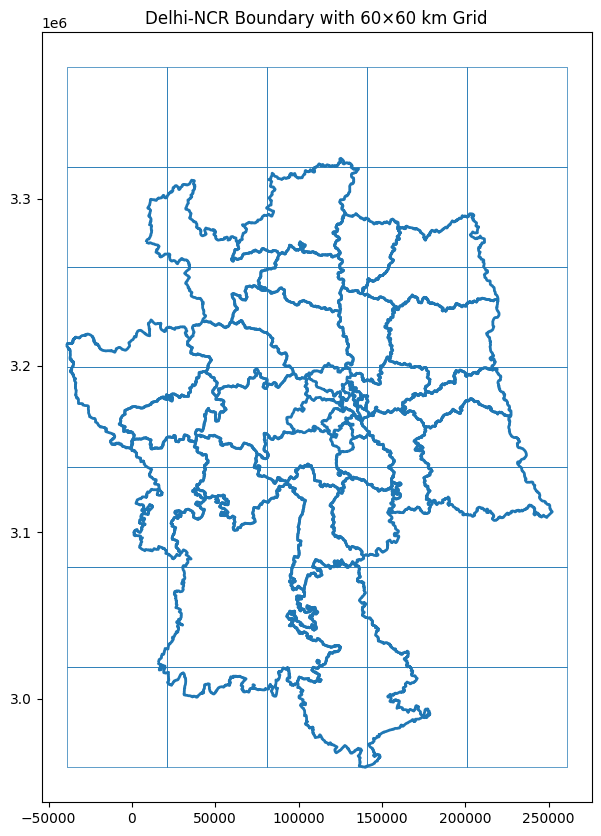

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

ncr_utm.boundary.plot(ax=ax, linewidth=2)
grid_gdf.boundary.plot(ax=ax, linewidth=0.5)

ax.set_title("Delhi-NCR Boundary with 60×60 km Grid")

plt.savefig("/kaggle/working/ncr_grid_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
def parse_coordinates(filename):
    name = filename.replace(".png", "")
    lat, lon = name.split("_")
    return float(lat), float(lon)


image_folder = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

image_files = [f for f in os.listdir(image_folder) if f.endswith(".png")]

print("Total images before filtering:", len(image_files))

points = []
filenames = []

for fname in image_files:
    lat, lon = parse_coordinates(fname)
    points.append(Point(lon, lat))
    filenames.append(fname)

points_gdf = gpd.GeoDataFrame(
    {"filename": filenames},
    geometry=points,
    crs="EPSG:4326"
)

Total images before filtering: 9216


In [17]:
points_utm = points_gdf.to_crs(epsg=32644)

points_inside = gpd.sjoin(points_utm, ncr_utm, predicate="within")

print("Images inside NCR:", len(points_inside))

Images inside NCR: 8015


The filtered image centers inside the NCR boundary are visualized below.

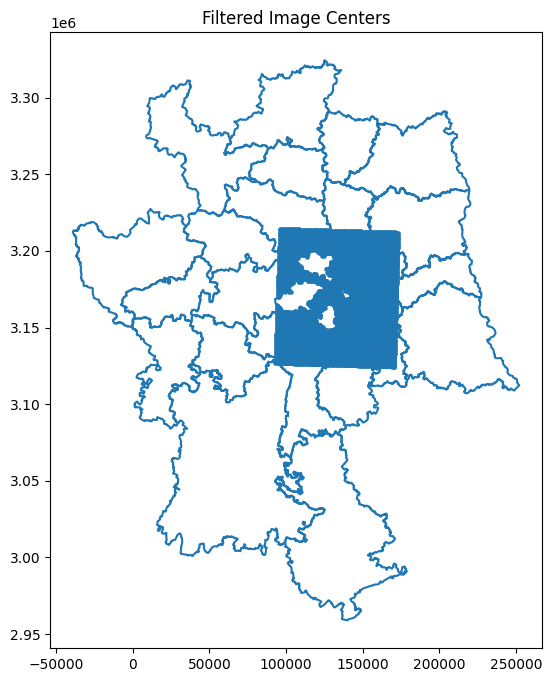

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

ncr_utm.boundary.plot(ax=ax)
points_inside.plot(ax=ax, markersize=5)

ax.set_title("Filtered Image Centers")
plt.show()

## Q2 – Label Construction & Dataset Preparation

For each filtered image, a corresponding 128×128 land-cover patch is extracted from the ESA WorldCover raster using the image center coordinates.  
The dominant (mode) land-cover class within each patch is assigned as the label.

ESA class codes are then mapped to simplified land-use categories, followed by a stratified 60/40 train-test split.

In [19]:
raster_path = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/worldcover_bbox_delhi_ncr_2021.tif"

raster = rasterio.open(raster_path)
print("Raster CRS:", raster.crs)

points_geo = points_inside.to_crs(epsg=4326)
print("Total points for labeling:", len(points_geo))

Raster CRS: EPSG:4326
Total points for labeling: 8015


In [20]:
def extract_label_patch(raster, lon, lat, patch_size=128):

    row, col = raster.index(lon, lat)
    half = patch_size // 2

    window = Window(col - half, row - half, patch_size, patch_size)
    patch = raster.read(1, window=window)

    patch = patch[patch != raster.nodata]

    if patch.size == 0:
        return None

    values, counts = np.unique(patch, return_counts=True)
    return int(values[np.argmax(counts)])

labels = []
image_list = []

for _, row in points_geo.iterrows():
    lon = row.geometry.x
    lat = row.geometry.y

    label = extract_label_patch(raster, lon, lat)

    if label is not None:
        labels.append(label)
        image_list.append(row["filename"])

print("Total labeled images:", len(labels))

Total labeled images: 8015


In [21]:
def map_class(code):
    if code == 50:
        return "Built-up"
    if code in [10, 20, 30]:
        return "Vegetation"
    if code == 40:
        return "Cropland"
    if code == 80:
        return "Water"
    return "Others"

simplified_labels = [map_class(c) for c in labels]

class_counts = Counter(simplified_labels)
print(class_counts)

Counter({'Cropland': 5474, 'Built-up': 1778, 'Vegetation': 754, 'Water': 7, 'Others': 2})


In [22]:
X = image_list
y = simplified_labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4809
Test size: 3206


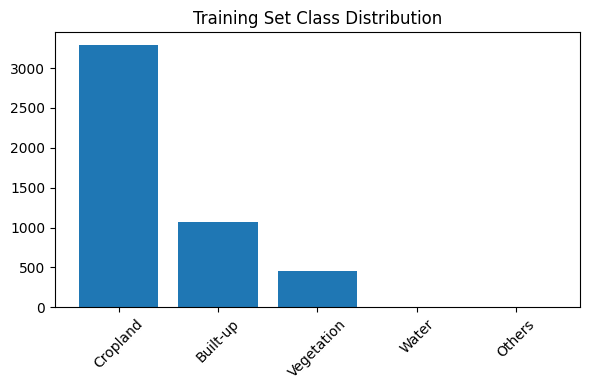

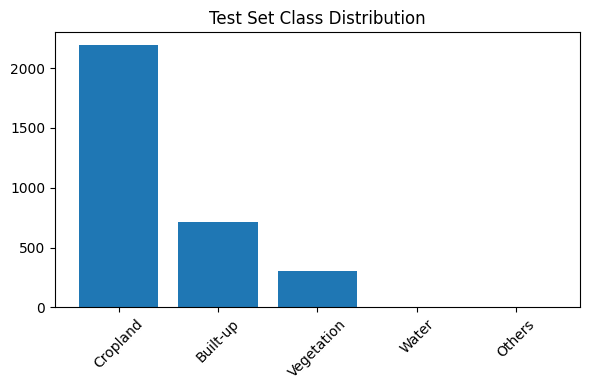

In [23]:
def plot_distribution(labels, title, save_path=None):
    counts = Counter(labels)
    classes = list(counts.keys())
    values = list(counts.values())

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(classes, values)
    ax.set_title(title)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

plot_distribution(
    y_train,
    "Training Set Class Distribution",
    save_path="/kaggle/working/train_distribution.png"
)

plot_distribution(
    y_test,
    "Test Set Class Distribution",
    save_path="/kaggle/working/test_distribution.png"
)

## Q3 – CNN Model Training & Supervised Evaluation

A ResNet18 model is trained for land-use classification using the labeled Sentinel-2 image patches.  
To address class imbalance, class-weighted CrossEntropy loss is used.  
Model performance is evaluated using overall accuracy and Macro F1-score.

In [24]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

class_names = label_encoder.classes_
print("Classes:", class_names)

Classes: ['Built-up' 'Cropland' 'Others' 'Vegetation' 'Water']


In [25]:
class SentinelDataset(Dataset):
    def __init__(self, image_folder, image_files, labels, transform=None):
        self.image_folder = image_folder
        self.image_files = image_files
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_folder, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
])

image_folder = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

train_dataset = SentinelDataset(image_folder, X_train, y_train_encoded, transform)
test_dataset = SentinelDataset(image_folder, X_test, y_test_encoded, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Compute class weights
train_counts = Counter(y_train_encoded)
num_classes = len(class_names)
total_samples = len(y_train_encoded)

class_weights = [
    total_samples / (num_classes * train_counts[i])
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [27]:
epochs = 25

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/25 - Loss: 0.6011
Epoch 2/25 - Loss: 0.3523
Epoch 3/25 - Loss: 0.3644
Epoch 4/25 - Loss: 0.2367
Epoch 5/25 - Loss: 0.1741
Epoch 6/25 - Loss: 0.1804
Epoch 7/25 - Loss: 0.1455
Epoch 8/25 - Loss: 0.1175
Epoch 9/25 - Loss: 0.0881
Epoch 10/25 - Loss: 0.0904
Epoch 11/25 - Loss: 0.0527
Epoch 12/25 - Loss: 0.0711
Epoch 13/25 - Loss: 0.0730
Epoch 14/25 - Loss: 0.0685
Epoch 15/25 - Loss: 0.2223
Epoch 16/25 - Loss: 0.1408
Epoch 17/25 - Loss: 0.0792
Epoch 18/25 - Loss: 0.0736
Epoch 19/25 - Loss: 0.0533
Epoch 20/25 - Loss: 0.0602
Epoch 21/25 - Loss: 0.0498
Epoch 22/25 - Loss: 0.0245
Epoch 23/25 - Loss: 0.0334
Epoch 24/25 - Loss: 0.0349
Epoch 25/25 - Loss: 0.0495


In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print("Test Accuracy:", accuracy)
print("Macro F1 Score:", f1)

Test Accuracy: 0.9332501559575795
Macro F1 Score: 0.8105113430901613


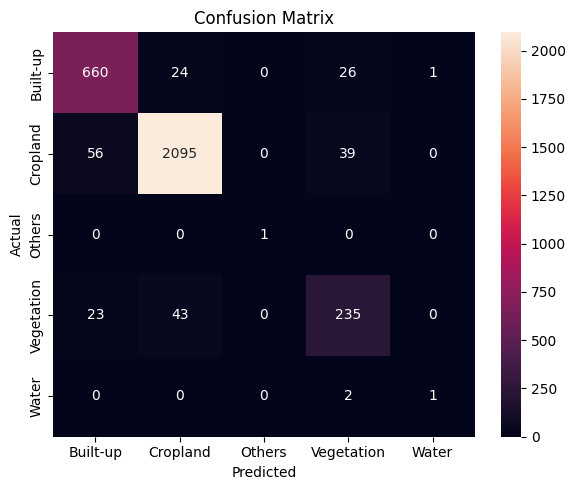

In [29]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

fig.tight_layout()
fig.savefig("/kaggle/working/confusion_matrix.png", dpi=300)

plt.show()